# 5 — Model Evaluation
## Brain Tumor Segmentation — U-Net on BRISC 2025
### Comprehensive evaluation of the trained model on the test set

In [1]:
import subprocess
subprocess.run([
    'pip', 'install', 'seaborn', '--quiet'])
print("✅ Seaborn installed!")

✅ Seaborn installed!


In [2]:
# Cell 2 — Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("All imports done!")
print(f"   TensorFlow version: {tf.__version__}")

All imports done!
   TensorFlow version: 2.10.0


In [3]:
# Cell 3 — Paths and Config
BEST_MODEL_PATH = '../models/best_model.keras'
X_TEST_PATH     = '../data/X_test.npy'
Y_TEST_PATH     = '../data/Y_test.npy'
OUTPUT_PATH     = '../outputs/'

os.makedirs(OUTPUT_PATH, exist_ok=True)

print(" Paths configured!")
print(f"   Model  : {BEST_MODEL_PATH}")
print(f"   X_test : {X_TEST_PATH}")
print(f"   Y_test : {Y_TEST_PATH}")

 Paths configured!
   Model  : ../models/best_model.keras
   X_test : ../data/X_test.npy
   Y_test : ../data/Y_test.npy


In [4]:
# Cell 4 — Custom Loss and Metric Functions
import tensorflow.keras.backend as K

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

print(" Custom functions defined!")

 Custom functions defined!


In [5]:
# Cell 5 — Load Model and Test Data
print("Loading model...")
model = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        'bce_dice_loss': bce_dice_loss,
        'dice_coef'    : dice_coef,
        'iou'          : iou
    }
)
print(" Model loaded!")

print("\nLoading test data...")
X_test = np.load(X_TEST_PATH).astype(np.float32)
Y_test = np.load(Y_TEST_PATH).astype(np.float32)

if len(Y_test.shape) == 3:
    Y_test = np.expand_dims(Y_test, axis=-1)

print(f" Test data loaded!")
print(f"   X_test shape: {X_test.shape}")
print(f"   Y_test shape: {Y_test.shape}")

Loading model...
 Model loaded!

Loading test data...
 Test data loaded!
   X_test shape: (860, 256, 256, 3)
   Y_test shape: (860, 256, 256, 1)


In [6]:
# Cell 6 — Overall Test Set Metrics
print("Evaluating model on test set...")

# Use smaller batch size to avoid OOM during evaluation
results = model.evaluate(X_test, Y_test, verbose=1, batch_size=2)

print("\n" + "="*50)
print("   FINAL TEST SET RESULTS")
print("="*50)
print(f"   Loss       : {results[0]:.4f}")
print(f"   Dice Score : {results[1]:.4f}")
print(f"   IoU        : {results[2]:.4f}")
print(f"   Accuracy   : {results[3]:.4f}")
print("="*50)

if results[1] >= 0.90:
    print("\n EXCELLENT! Dice >= 0.90")
elif results[1] >= 0.75:
    print("\n GOOD! Dice >= 0.75")
else:
    print("\n Needs improvement")

Evaluating model on test set...
430/430 [==============================] - 15s 24ms/step - loss: 0.2008 - dice_coef: 0.8280 - iou: 0.7412 - accuracy: 0.9896

   FINAL TEST SET RESULTS
   Loss       : 0.2008
   Dice Score : 0.8280
   IoU        : 0.7412
   Accuracy   : 0.9896

 GOOD! Dice >= 0.75


In [7]:
# Cell 7 — Generate Predictions on Entire Test Set
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

print("Generating predictions on CPU to avoid OOM...")

# Force predictions to run on CPU
with tf.device('/CPU:0'):
    Y_pred = model.predict(X_test, verbose=1, batch_size=2)

Y_pred_binary = (Y_pred > 0.5).astype(np.float32)

print(f" Predictions generated!")
print(f"   Y_pred shape       : {Y_pred.shape}")
print(f"   Y_pred_binary shape: {Y_pred_binary.shape}")
print(f"   Threshold used     : 0.5")

Generating predictions on CPU to avoid OOM...
430/430 [==============================] - 116s 269ms/step
 Predictions generated!
   Y_pred shape       : (860, 256, 256, 1)
   Y_pred_binary shape: (860, 256, 256, 1)
   Threshold used     : 0.5


Computing confusion matrix...

   CONFUSION MATRIX RESULTS
   True Negatives  (TN): 55,244,802 (98.02%)
   False Positives (FP): 220,740 (0.39%)
   False Negatives (FN): 119,358 (0.21%)
   True Positives  (TP): 776,060 (1.38%)


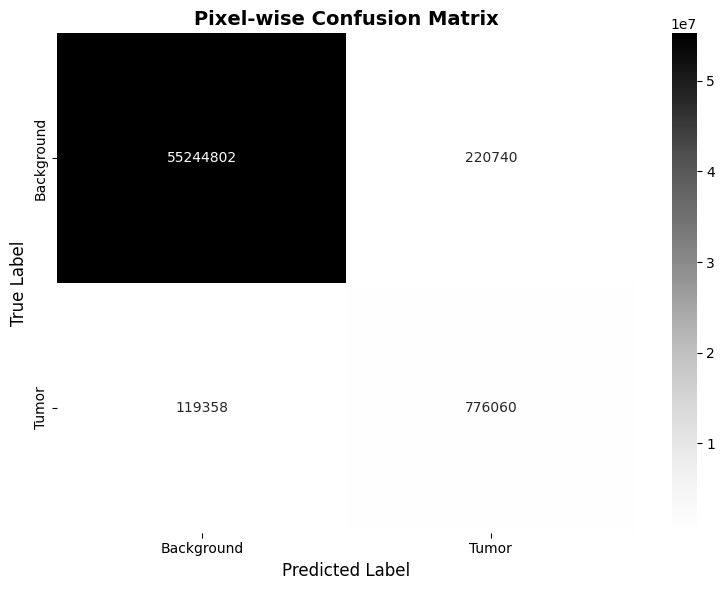

✅ Confusion matrix saved!


In [8]:
# Cell 8 — Pixel-wise Confusion Matrix
print("Computing confusion matrix...")

y_true_flat = Y_test.flatten().astype(int)
y_pred_flat = Y_pred_binary.flatten().astype(int)

cm = confusion_matrix(y_true_flat, y_pred_flat)

tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp

print(f"\n{'='*50}")
print("   CONFUSION MATRIX RESULTS")
print(f"{'='*50}")
print(f"   True Negatives  (TN): {tn:,} ({100*tn/total:.2f}%)")
print(f"   False Positives (FP): {fp:,} ({100*fp/total:.2f}%)")
print(f"   False Negatives (FN): {fn:,} ({100*fn/total:.2f}%)")
print(f"   True Positives  (TP): {tp:,} ({100*tp/total:.2f}%)")

# Plot confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greys',
    xticklabels=['Background', 'Tumor'],
    yticklabels=['Background', 'Tumor'],
    ax=ax
)
ax.set_title('Pixel-wise Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

Computing per-image Dice scores...

   PER IMAGE DICE ANALYSIS
   Mean Dice   : 0.8124
   Std Dice    : 0.2515
   Min Dice    : 0.0000
   Max Dice    : 0.9871
   Dice >= 0.90: 496 images
   Dice >= 0.75: 671 images
   Dice < 0.50 : 87 images


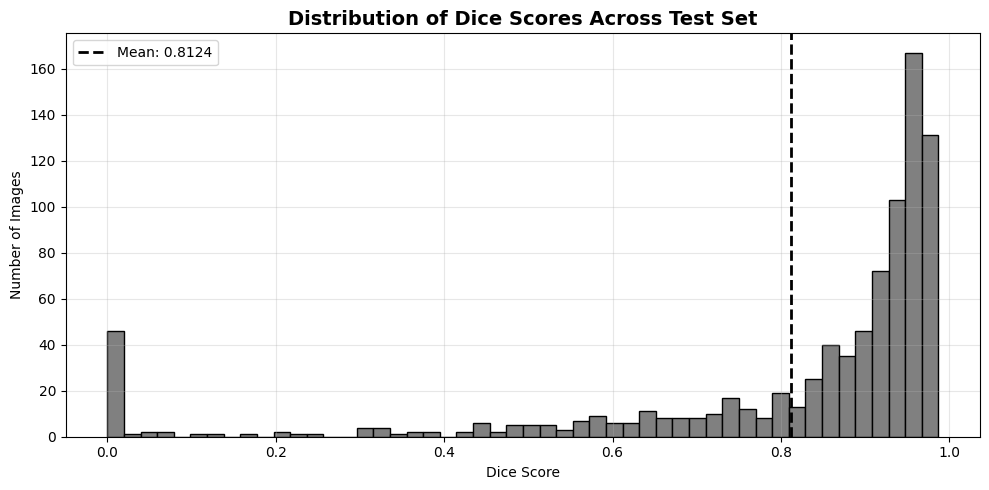

✅ Dice distribution saved!


In [9]:
# Cell 9 — Per Image Dice Score Analysis
print("Computing per-image Dice scores...")

dice_scores = []
for i in range(len(X_test)):
    y_true = Y_test[i].flatten()
    y_pred = Y_pred_binary[i].flatten()
    
    intersection = np.sum(y_true * y_pred)
    dice = (2. * intersection + 1e-6) / (np.sum(y_true) + np.sum(y_pred) + 1e-6)
    dice_scores.append(dice)

dice_scores = np.array(dice_scores)

print(f"\n{'='*50}")
print("   PER IMAGE DICE ANALYSIS")
print(f"{'='*50}")
print(f"   Mean Dice   : {dice_scores.mean():.4f}")
print(f"   Std Dice    : {dice_scores.std():.4f}")
print(f"   Min Dice    : {dice_scores.min():.4f}")
print(f"   Max Dice    : {dice_scores.max():.4f}")
print(f"   Dice >= 0.90: {(dice_scores >= 0.90).sum()} images")
print(f"   Dice >= 0.75: {(dice_scores >= 0.75).sum()} images")
print(f"   Dice < 0.50 : {(dice_scores < 0.50).sum()} images")

# Plot distribution
plt.figure(figsize=(10, 5))
plt.hist(dice_scores, bins=50, color='gray', edgecolor='black')
plt.axvline(dice_scores.mean(), color='black', linestyle='--',
            linewidth=2, label=f'Mean: {dice_scores.mean():.4f}')
plt.title('Distribution of Dice Scores Across Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Dice Score')
plt.ylabel('Number of Images')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}dice_distribution.png', dpi=150)
plt.show()
print("✅ Dice distribution saved!")

Finding best predictions...


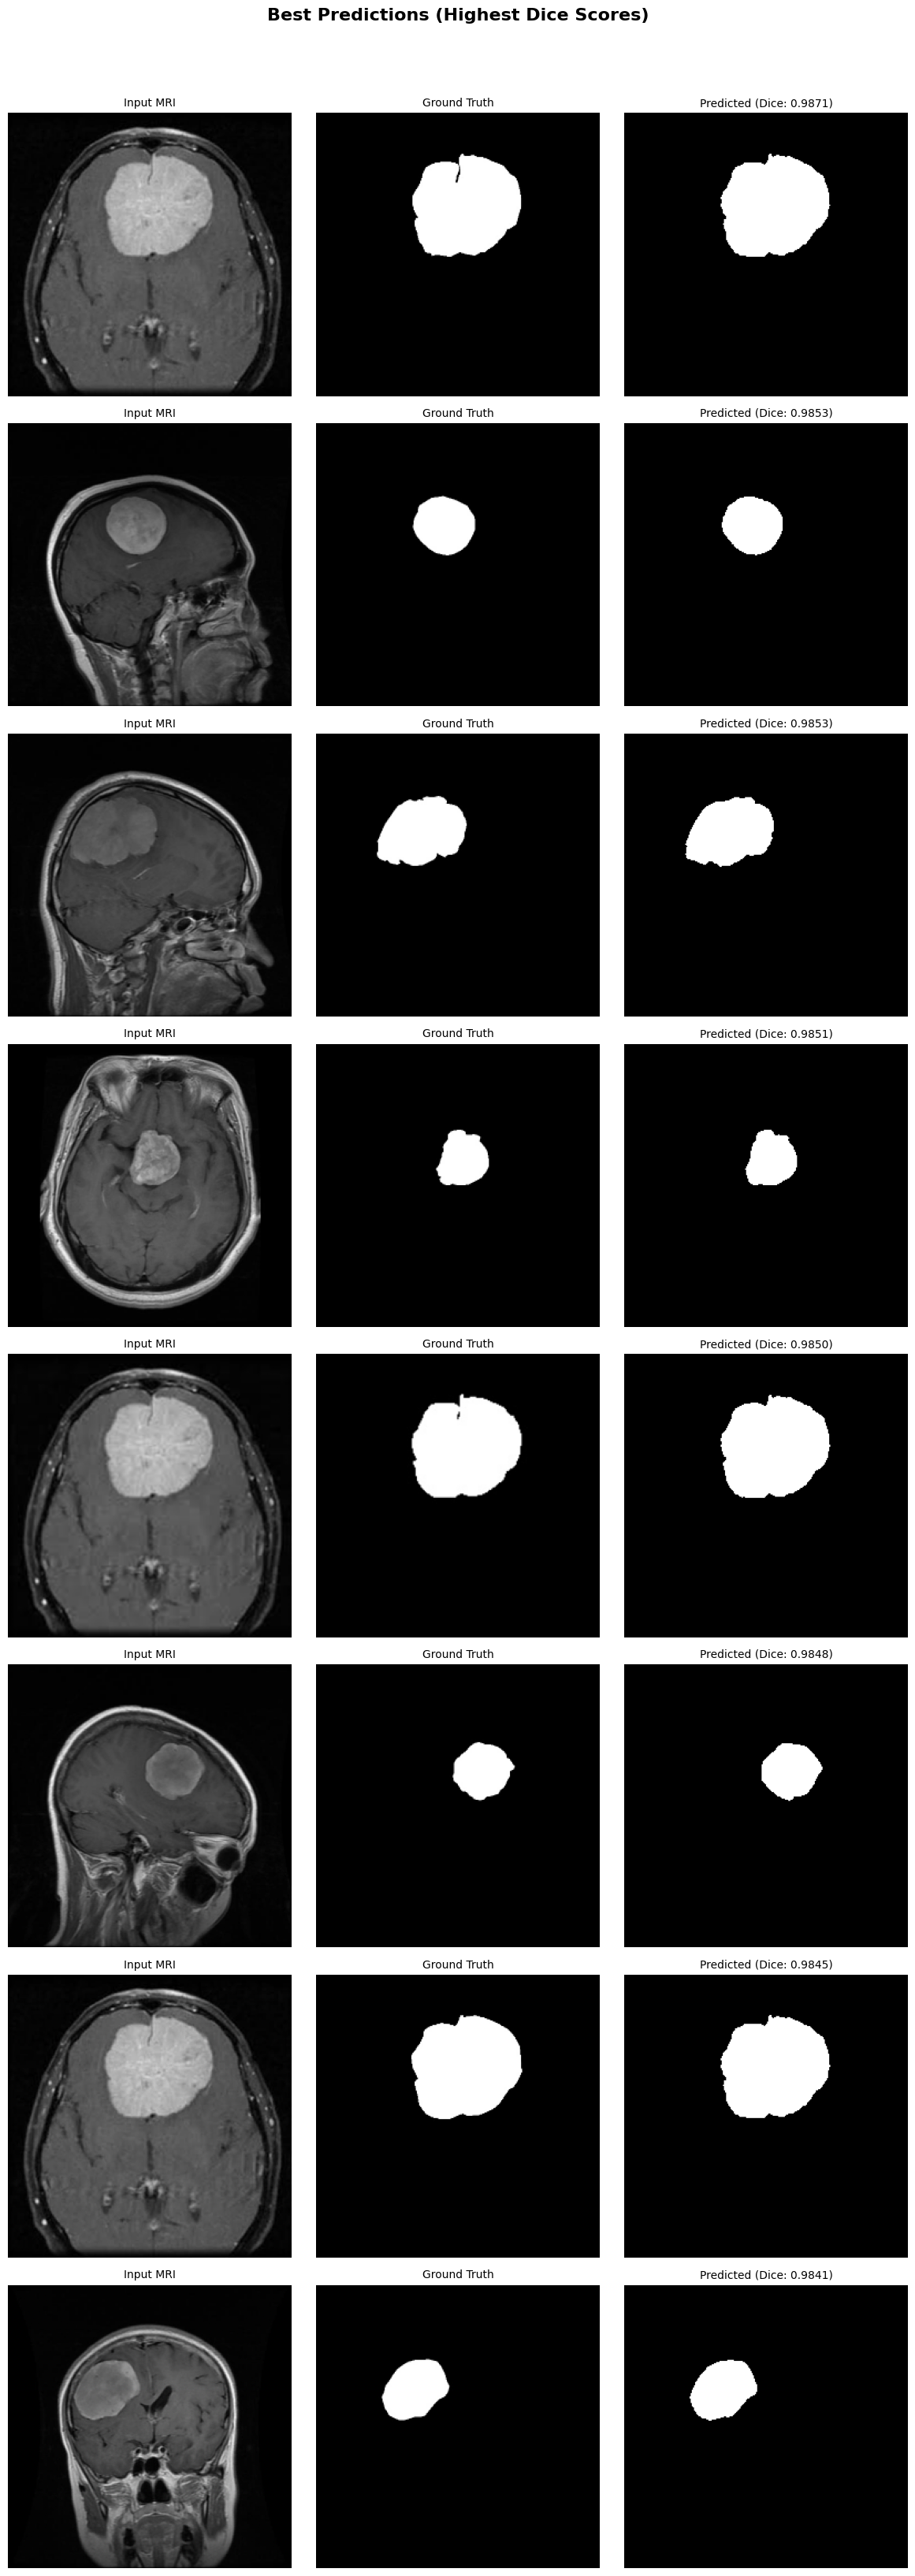

 Best predictions saved!


In [10]:
# Cell 10 — Best Predictions Visualization
print("Finding best predictions...")

best_idx = np.argsort(dice_scores)[-8:][::-1]

fig, axes = plt.subplots(8, 3, figsize=(12, 32))
fig.suptitle('Best Predictions (Highest Dice Scores)',
             fontsize=16, fontweight='bold', y=1.02)

for i, idx in enumerate(best_idx):
    axes[i, 0].imshow(X_test[idx])
    axes[i, 0].set_title(f'Input MRI', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(Y_test[idx].squeeze(), cmap='gray')
    axes[i, 1].set_title(f'Ground Truth', fontsize=10)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(Y_pred_binary[idx].squeeze(), cmap='gray')
    axes[i, 2].set_title(f'Predicted (Dice: {dice_scores[idx]:.4f})', fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}best_predictions.png', dpi=150)
plt.show()
print(" Best predictions saved!")

Finding worst predictions...


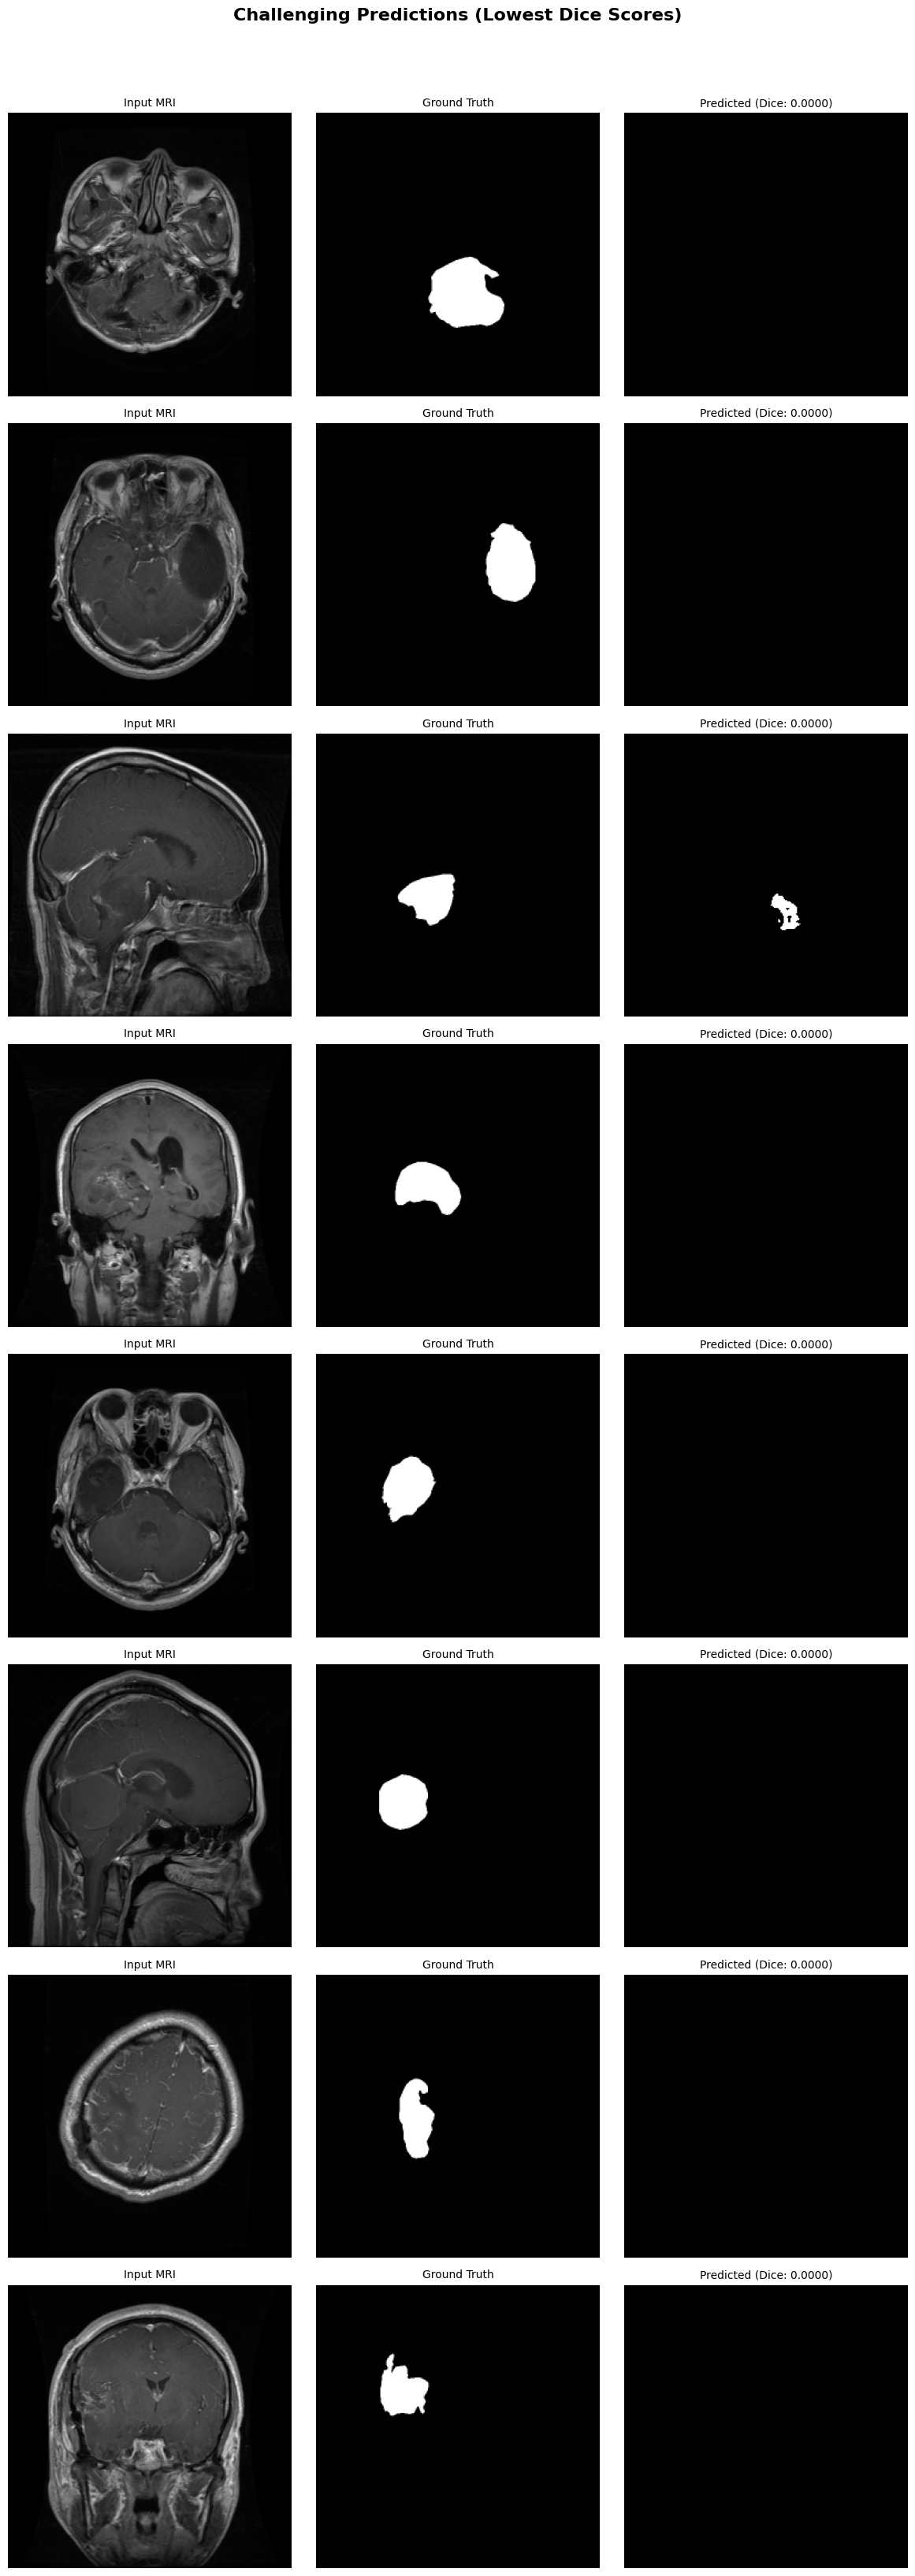

 Worst predictions saved!


In [11]:
# Cell 11 — Worst Predictions Visualization
print("Finding worst predictions...")

worst_idx = np.argsort(dice_scores)[:8]

fig, axes = plt.subplots(8, 3, figsize=(12, 32))
fig.suptitle('Challenging Predictions (Lowest Dice Scores)',
             fontsize=16, fontweight='bold', y=1.02)

for i, idx in enumerate(worst_idx):
    axes[i, 0].imshow(X_test[idx])
    axes[i, 0].set_title(f'Input MRI', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(Y_test[idx].squeeze(), cmap='gray')
    axes[i, 1].set_title(f'Ground Truth', fontsize=10)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(Y_pred_binary[idx].squeeze(), cmap='gray')
    axes[i, 2].set_title(f'Predicted (Dice: {dice_scores[idx]:.4f})', fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}worst_predictions.png', dpi=150)
plt.show()
print(" Worst predictions saved!")

Creating overlay visualizations...


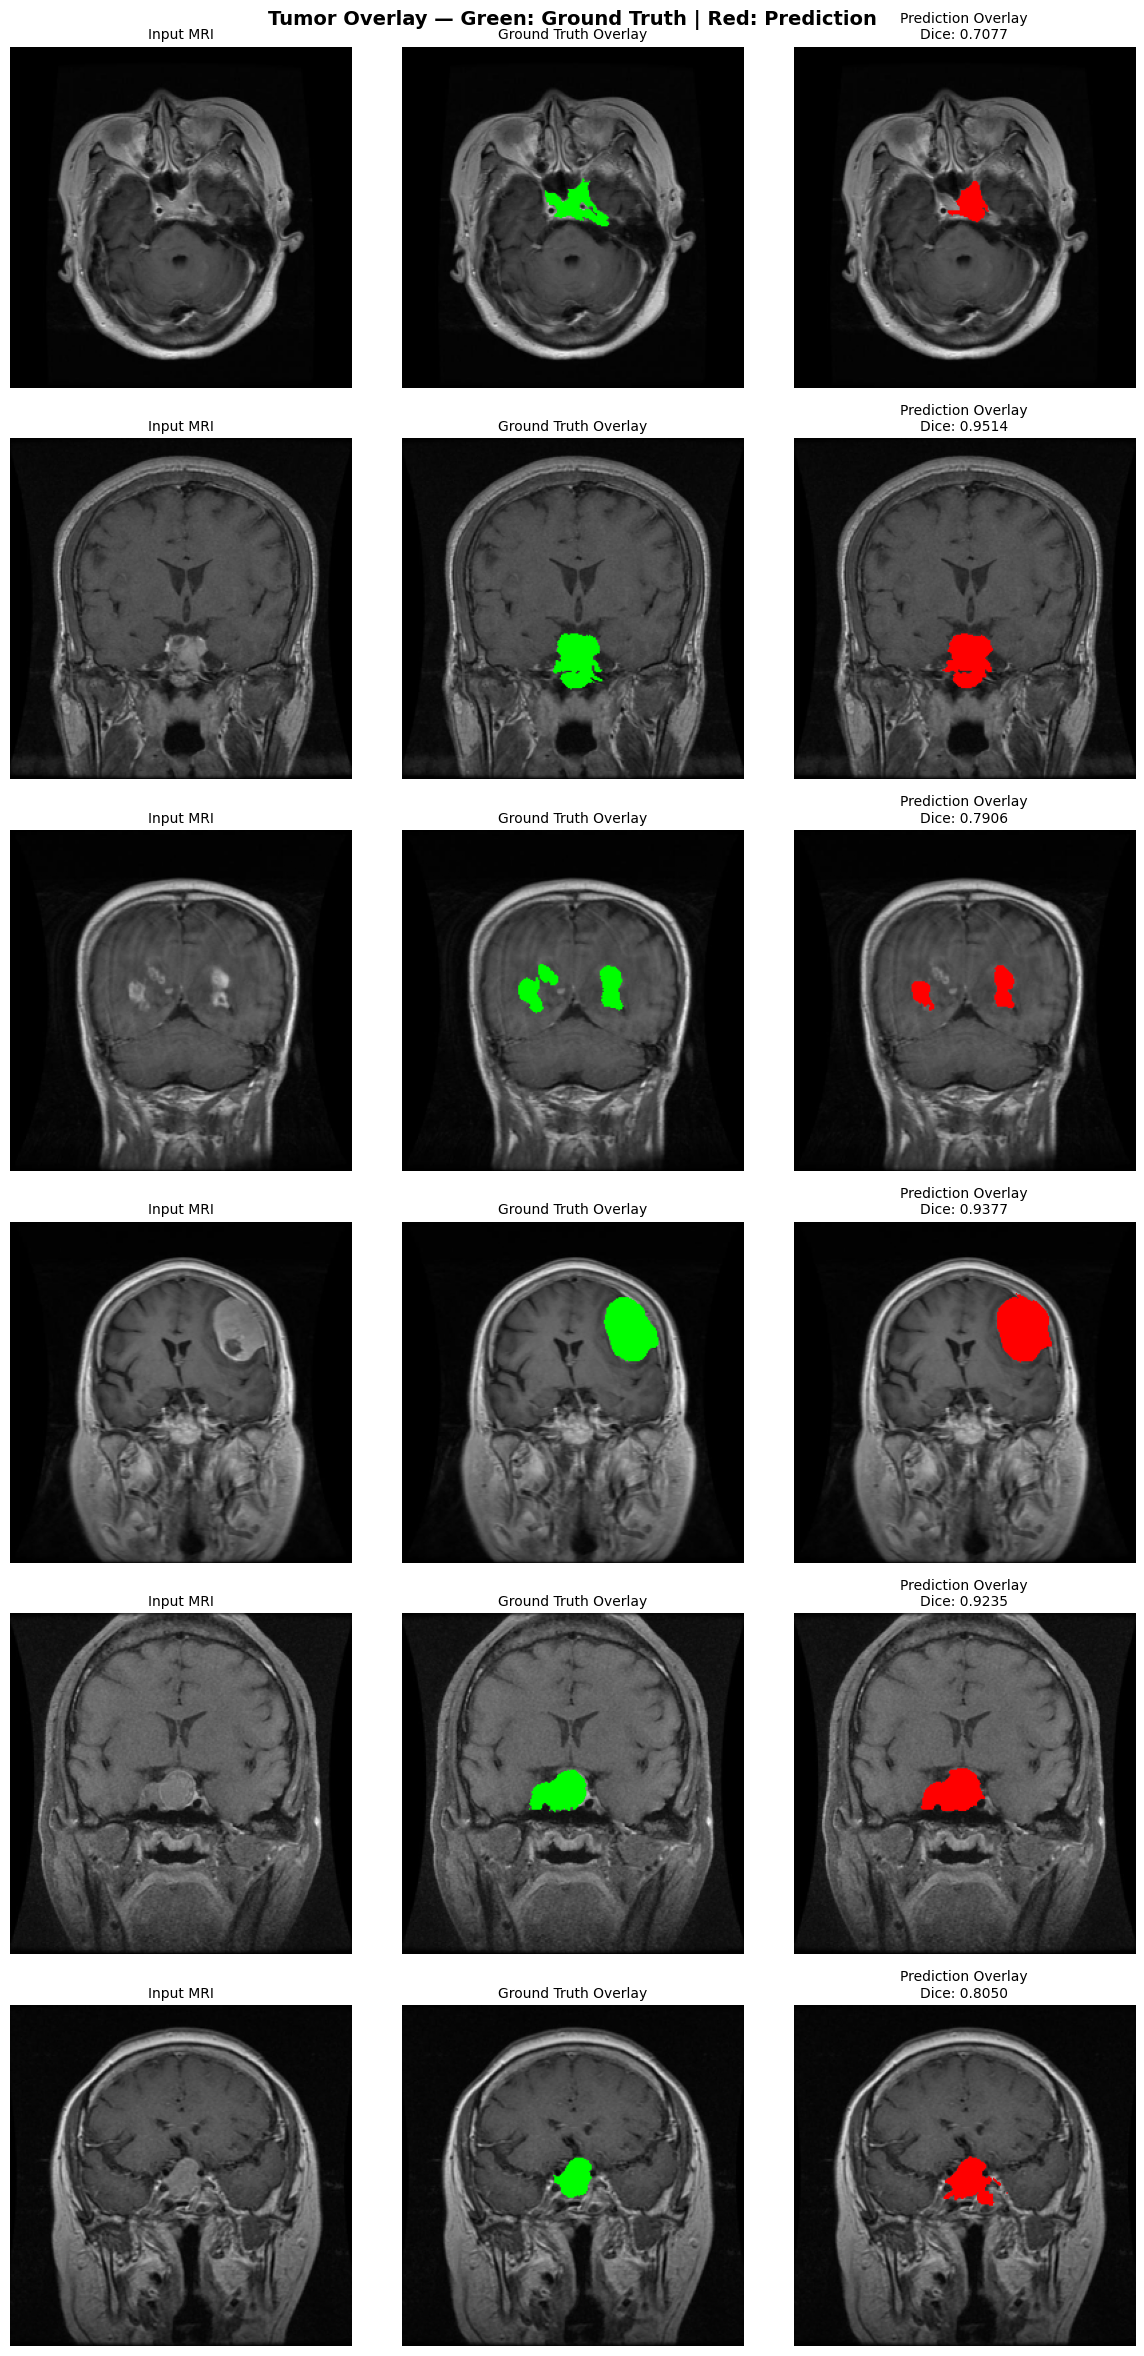

 Overlay visualization saved!


In [12]:
# Cell 12 — Tumor Overlay Visualization
print("Creating overlay visualizations...")

sample_idx = np.random.choice(len(X_test), 6, replace=False)

fig, axes = plt.subplots(6, 3, figsize=(12, 24))
fig.suptitle('Tumor Overlay — Green: Ground Truth | Red: Prediction',
             fontsize=14, fontweight='bold')

for i, idx in enumerate(sample_idx):
    img = X_test[idx]
    gt  = Y_test[idx].squeeze()
    pred = Y_pred_binary[idx].squeeze()

    # Original
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Input MRI', fontsize=10)
    axes[i, 0].axis('off')

    # Ground truth overlay (green)
    overlay_gt = img.copy()
    overlay_gt[gt > 0.5, 0] = 0
    overlay_gt[gt > 0.5, 1] = 1
    overlay_gt[gt > 0.5, 2] = 0
    axes[i, 1].imshow(overlay_gt)
    axes[i, 1].set_title('Ground Truth Overlay', fontsize=10)
    axes[i, 1].axis('off')

    # Prediction overlay (red)
    overlay_pred = img.copy()
    overlay_pred[pred > 0.5, 0] = 1
    overlay_pred[pred > 0.5, 1] = 0
    overlay_pred[pred > 0.5, 2] = 0
    axes[i, 2].imshow(overlay_pred)
    axes[i, 2].set_title(f'Prediction Overlay\nDice: {dice_scores[idx]:.4f}', fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}overlay_visualization.png', dpi=150)
plt.show()
print(" Overlay visualization saved!")

In [13]:
# Cell 13 — Final Evaluation Summary
print("\n" + "="*60)
print("   COMPLETE EVALUATION SUMMARY")
print("="*60)
print(f"\n📊 Test Set Size     : {len(X_test)} images")
print(f"\n🎯 Overall Metrics:")
print(f"   Dice Score       : {results[1]:.4f}")
print(f"   IoU              : {results[2]:.4f}")
print(f"   Pixel Accuracy   : {results[3]:.4f}")
print(f"\n📈 Per-Image Analysis:")
print(f"   Mean Dice        : {dice_scores.mean():.4f}")
print(f"   Std Deviation    : {dice_scores.std():.4f}")
print(f"   Best Dice        : {dice_scores.max():.4f}")
print(f"   Worst Dice       : {dice_scores.min():.4f}")
print(f"\n🏅 Performance Breakdown:")
print(f"   Excellent (≥0.90): {(dice_scores >= 0.90).sum()} images ({100*(dice_scores >= 0.90).mean():.1f}%)")
print(f"   Good      (≥0.75): {(dice_scores >= 0.75).sum()} images ({100*(dice_scores >= 0.75).mean():.1f}%)")
print(f"   Fair      (≥0.50): {(dice_scores >= 0.50).sum()} images ({100*(dice_scores >= 0.50).mean():.1f}%)")
print(f"   Poor      (<0.50) : {(dice_scores < 0.50).sum()} images ({100*(dice_scores < 0.50).mean():.1f}%)")
print(f"\n📁 Saved Outputs:")
print(f"   confusion_matrix.png")
print(f"   dice_distribution.png")
print(f"   best_predictions.png")
print(f"   worst_predictions.png")
print(f"   overlay_visualization.png")
print("\n" + "="*60)
print("   5_evaluation.ipynb COMPLETE! ✅")
print("="*60)


   COMPLETE EVALUATION SUMMARY

📊 Test Set Size     : 860 images

🎯 Overall Metrics:
   Dice Score       : 0.8280
   IoU              : 0.7412
   Pixel Accuracy   : 0.9896

📈 Per-Image Analysis:
   Mean Dice        : 0.8124
   Std Deviation    : 0.2515
   Best Dice        : 0.9871
   Worst Dice       : 0.0000

🏅 Performance Breakdown:
   Excellent (≥0.90): 496 images (57.7%)
   Good      (≥0.75): 671 images (78.0%)
   Fair      (≥0.50): 773 images (89.9%)
   Poor      (<0.50) : 87 images (10.1%)

📁 Saved Outputs:
   confusion_matrix.png
   dice_distribution.png
   best_predictions.png
   worst_predictions.png
   overlay_visualization.png

   5_evaluation.ipynb COMPLETE! ✅
